# Superstore Discount Impact and Regional Profitability Analysis

**Dataset:** [Superstore Sales Dataset (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) (Original) 

To demonstrate the data-cleaning workflow, minor missing values and duplicates were synthetically introduced into an otherwise clean dataset. 

**Author:** Imaan Mutayyab
**Date:** 25th August 2026
**Cluster/Track:** C2-Data Scientist
**ID:** DC-442


This notebook contains structured 5 sections:
1. Problem Statement & Dataset Overview
2. Data Cleaning & Quality Audit
3. Exploratory Data Analysis & Manipulation
4. Distribution & Visual Analysis
5. Key Business Takeaways / Conclusion


## 1. Problem Statement & Dataset Overview

**Business Problem:**
Retailers often chase sales volume as a success metric, but high sales don't guarantee high profit; discounting,
shipping costs, and regional inefficiencies can quietly erode margins. This project audits a superstore's transaction
data to find where the business is profitable, where it's wasting money, and why - so authorities can make targeted
decisions on pricing, discounting policy, and regional strategy instead of just simply guessing or having assumptions.

**Dataset Overview:**
The dataset contains ~9,994 individual order-line transactions from a US-based superstore, spanning four years.
Each row represents one product line item within a customer order, and includes:

- **Order info:** Order ID, Order Date, Ship Date, Ship Mode
- **Customer info:** Customer ID, Customer Name, Segment (Consumer / Corporate / Home Office)
- **Location info:** Country, City, State, Postal Code, Region
- **Product info:** Category, Sub-Category, Product Name
- **Financial metrics:** Sales, Quantity, Discount, Profit

**Target Objectives:**
- Identify which product categories/sub-categories are profitable vs. loss-making
- Quantify the relationship between discount level and profit
- Compare regional/state efficiency (profit per order), not just raw sales volume
- Assess whether shipping mode affects profitability or delivery speed
- Detect seasonal patterns in sales and profit
- Determine which customer segment yields the best profit margin per order


In [32]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
#Loading the data set
data = "Sample_Superstore_messy.csv" 
df = pd.read_csv(data, encoding='latin1')
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset shape: 10004 rows, 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [65]:
# Structural overview of the dataset: column names, non-null counts, and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10004 entries, 0 to 10003
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10004 non-null  int64  
 1   Order ID       10004 non-null  object 
 2   Order Date     10004 non-null  object 
 3   Ship Date      10004 non-null  object 
 4   Ship Mode      10004 non-null  object 
 5   Customer ID    10004 non-null  object 
 6   Customer Name  10004 non-null  object 
 7   Segment        10004 non-null  object 
 8   Country        10004 non-null  object 
 9   City           10004 non-null  object 
 10  State          10004 non-null  object 
 11  Postal Code    9989 non-null   float64
 12  Region         10004 non-null  object 
 13  Product ID     10004 non-null  object 
 14  Category       10004 non-null  object 
 15  Sub-Category   10004 non-null  object 
 16  Product Name   10004 non-null  object 
 17  Sales          9996 non-null   float64
 18  Quanti

In [66]:
# Quick look at target/key numeric columns before any cleaning
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe()

,Sales,Quantity,Discount,Profit
count,9996.000000,10004.000000,10004.000000,10004.000000
mean,229.965142,3.789784,0.156187,28.607124
std,623.233820,2.224861,0.206389,234.158748
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.310000,2.000000,0.000000,1.727550
50%,54.686000,3.000000,0.200000,8.643600
75%,209.947500,5.000000,0.200000,29.359500
max,22638.480000,14.000000,0.800000,8399.976000


## 2. Data Cleaning & Quality Audit

In this section we perform a full data-hygiene pass:
- Check and document missing values (before/after)
- Identify and remove duplicate rows
- Convert data types (dates to datetime, IDs/categoricals to appropriate types)
- Explain the reasoning behind every cleaning decision

In [67]:
# Missing Values Audit (BEFORE cleaning) ---
missing_before = df.isnull().sum()
missing_before_pct = (missing_before / len(df)) * 100

missing_report_before = pd.DataFrame({
    'Missing Count': missing_before,
    'Missing %': missing_before_pct.round(2)
}).sort_values(by='Missing Count', ascending=False)

print("Missing Values BEFORE Cleaning:")
missing_report_before[missing_report_before['Missing Count'] > 0]

Missing Values BEFORE Cleaning:


,Missing Count,Missing %
Postal Code,15,0.15
Sales,8,0.08


#### Handle Missing Values
**Postal Code:** geographic identifier, not used in any numeric aggregation or model input,
so instead of dropping rows (losing valid Sales/Profit data), we impute with a placeholder (0).

**Sales:** a core numeric/financial metric, so imputing with 0 would distort totals and averages.
Reasoning: so we impute missing Sales with the MEDIAN sales value for that row's Sub-Category,
since price naturally varies a lot by product type — using the overall median would be inaccurate.

In [68]:
if 'Postal Code' in df.columns:
    missing_postal_count = df['Postal Code'].isnull().sum()
    df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)
    print(f"Imputed {missing_postal_count} missing Postal Code values with 0 (placeholder) "
          f"since Postal Code is not used in any numeric/statistical analysis.")
else:
    print("No 'Postal Code' column found — skipping this step.")

if 'Sales' in df.columns:
    missing_sales_count = df['Sales'].isnull().sum()
    df['Sales'] = df.groupby('Sub-Category', observed=True)['Sales'].transform(
        lambda x: x.fillna(x.median())
    )
    print(f"Imputed {missing_sales_count} missing Sales values using the median Sales "
          f"for each Sub-Category (preserves realistic price variation by product type).")
else:
    print("No 'Sales' column found — skipping this step.")

#Verify no missing values remain in either column
print(f"\nRemaining missing values — Postal Code: {df['Postal Code'].isnull().sum()}, "
      f"Sales: {df['Sales'].isnull().sum()}")

Imputed 15 missing Postal Code values with 0 (placeholder) since Postal Code is not used in any numeric/statistical analysis.
Imputed 8 missing Sales values using the median Sales for each Sub-Category (preserves realistic price variation by product type).

Remaining missing values — Postal Code: 0, Sales: 0


#### Duplicate Removal
Exact duplicate rows would double-count Sales/Profit in our groupby aggregations,
artificially inflating regional and category totals — so they must be removed before any analysis.

In [69]:
#Duplicate Removal
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows found: {duplicate_count}")
df = df.drop_duplicates()
print(f"Shape after duplicate removal: {df.shape}")

Number of exact duplicate rows found: 10
Shape after duplicate removal: (9994, 21)


#### Data Type Conversion 
Convert **OrderDate and ShipDate** from string/object to proper date time objects.
This is required to extract date components (month, quarter, year) later, and to correctly calculate shipping delay as a numeric duration.

Convert **key categorical/text columns** to the 'category' dtype. Category dtype is more memory-efficient and speeds up groupby operations on columns with a limited number of repeated values.

In [70]:
#Data Type Conversions
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

categorical_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category', 'State']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("Data types after conversion:")
df.dtypes


Data types after conversion:


Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode              category
Customer ID              object
Customer Name            object
Segment                category
Country                  object
City                     object
State                  category
Postal Code               int64
Region                 category
Product ID               object
Category               category
Sub-Category           category
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [71]:
#Missing Values Audit (AFTER cleaning)
missing_after = df.isnull().sum()
print("Missing Values AFTER Cleaning:")
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else "No missing values remain.")

print(f"\nFinal cleaned dataset shape: {df.shape}")

Missing Values AFTER Cleaning:
No missing values remain.

Final cleaned dataset shape: (9994, 21)


**Cleaning Summary:**
- Postal Code missing values were imputed with a placeholder (0) since this field is not used in any statistical
  calculation because dropping rows would have discarded valid Sales/Profit data unnecessarily.
- Duplicate rows were removed to prevent inflated totals in later `groupby` aggregations.
- Order Date and Ship Date were converted to `datetime` to enable date-component feature engineering.
- Key categorical columns were converted to the `category` dtype for cleaner, faster grouping in later steps.


## 3. Exploratory Data Analysis & Manipulation

We generate summary statistics and engineer new features (date parts, shipping delay, profit margin,
profit-per-order) that will power the business questions in Section 4 and the conclusions in Section 5.


In [72]:
#Summary Statistics Table for continuous variables
continuous_cols = ['Sales', 'Profit', 'Discount', 'Quantity']

summary_stats = pd.DataFrame({
    'Mean': df[continuous_cols].mean(),
    'Median': df[continuous_cols].median(),
    'Std Dev': df[continuous_cols].std(),
    'IQR': df[continuous_cols].quantile(0.75) - df[continuous_cols].quantile(0.25),
    'Min': df[continuous_cols].min(),
    'Max': df[continuous_cols].max()
}).round(2)

summary_stats


,Mean,Median,Std Dev,IQR,Min,Max
Sales,229.83,54.43,623.24,192.65,0.44,22638.48
Profit,28.66,8.67,234.26,27.64,-6599.98,8399.98
Discount,0.16,0.20,0.21,0.20,0.00,0.80
Quantity,3.79,3.00,2.23,3.00,1.00,14.00


In [73]:
#Feature Engineering — Date Component Extraction
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.strftime('%b')
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order DayOfWeek'] = df['Order Date'].dt.day_name()

# Shipping Delay: number of days between order placement and shipment
df['Shipping Delay (Days)'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date', 'Order Year', 'Order Month Name', 'Order Quarter', 'Order DayOfWeek', 'Shipping Delay (Days)']].head()


,Order Date,Order Year,Order Month Name,Order Quarter,Order DayOfWeek,Shipping Delay (Days)
0,2016-11-08,2016,Nov,4,Tuesday,3
1,2016-11-08,2016,Nov,4,Tuesday,3
2,2016-06-12,2016,Jun,2,Sunday,4
3,2015-10-11,2015,Oct,4,Sunday,7
4,2015-10-11,2015,Oct,4,Sunday,7


In [74]:
#Feature Engineering — Ratio Features
# Profit Margin: Profit as a percentage of Sales for each order line
df['Profit Margin (%)'] = (df['Profit'] / df['Sales']) * 100

df[['Sales', 'Profit', 'Discount', 'Profit Margin (%)']].head()


,Sales,Profit,Discount,Profit Margin (%)
0,261.9600,41.9136,0.00,16.00
1,731.9400,219.5820,0.00,30.00
2,14.6200,6.8714,0.00,47.00
3,957.5775,-383.0310,0.45,-40.00
4,22.3680,2.5164,0.20,11.25


#### Question 1 - Category/Sub-Category Profitability

In [89]:
category_profit = df.groupby(['Category', 'Sub-Category'], observed=True).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit Margin (%)', 'mean'),
    Order_Count=('Order ID', 'nunique')
).round(2).sort_values(by='Total_Profit')

print("Sub-categories with NEGATIVE total profit (loss-making):")
category_profit[category_profit['Total_Profit'] < 0]
category_profit

Sub-categories with NEGATIVE total profit (loss-making):


Total_Sales  Total_Profit  Avg_Profit_Margin  \
Category        Sub-Category                                                 
Furniture       Tables          206965.53     -17725.48             -14.77   
                Bookcases       114880.00      -3472.56             -12.66   
Office Supplies Supplies         46673.54      -1189.10              11.20   
                Fasteners         3024.28        949.52              29.92   
Technology      Machines        189238.63       3384.76              -7.20   
Office Supplies Labels           12486.31       5546.25              42.97   
                Art              26755.43       6527.79              26.02   
                Envelopes        16476.40       6964.18              42.31   
Furniture       Furnishings      91762.40      13059.14              13.64   
Office Supplies Appliances      107532.16      18138.01             -15.69   
                Storage         223843.61      21278.83               8.91   
Furniture       Chairs          328449.10      26590.17               4.39   
Office Supplies Binders         203428.93      30221.76             -19.91   
                Paper            78484.13      34053.57              42.55   
Technology      Accessories     167380.32      41936.64              21.82   
                Phones          330007.05      44515.73              11.92   
                Copiers         149528.03      55617.82              31.72   

                              Order_Count  
Category        Sub-Category               
Furniture       Tables                307  
                Bookcases             224  
Office Supplies Supplies              187  
                Fasteners             215  
Technology      Machines              112  
Office Supplies Labels                346  
                Art                   731  
                Envelopes             249  
Furniture       Furnishings           877  
Office Supplies Appliances            451  
                Storage               777  
Furniture       Chairs                576  
Office Supplies Binders              1316  
                Paper                1191  
Technology      Accessories           718  
                Phones                814  
                Copiers                68

#### Question 2 - Discount Vs Profit
Bin discount into ranges to see the tipping point where discounting turns orders unprofitable


In [76]:
discount_bins = [-0.01, 0, 0.10, 0.20, 0.30, 0.50, 1.0]
discount_labels = ['0%', '1-10%', '11-20%', '21-30%', '31-50%', '51%+']
df['Discount Range'] = pd.cut(df['Discount'], bins=discount_bins, labels=discount_labels)

discount_impact = df.groupby('Discount Range', observed=True).agg(
    Avg_Profit_Margin=('Profit Margin (%)', 'mean'),
    Avg_Profit=('Profit', 'mean'),
    Order_Count=('Order ID', 'nunique')
).round(2)

discount_impact


,Avg_Profit_Margin,Avg_Profit,Order_Count
Discount Range,,,
0%,34.14,66.90,2644
1-10%,15.58,96.06,89
11-20%,17.49,24.74,2436
21-30%,-11.55,-45.68,211
31-50%,-29.61,-156.28,280
51%+,-113.80,-89.44,685


#### Question 3 - Regional/State Efficiency

In [77]:
region_efficiency = df.groupby(['Region', 'State'], observed=True).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique')
).round(2)

region_efficiency['Profit per Order'] = (region_efficiency['Total_Profit'] / region_efficiency['Order_Count']).round(2)
region_efficiency = region_efficiency.sort_values(by='Profit per Order', ascending=False)

print("Top 5 most EFFICIENT states (highest profit per order):")
display(region_efficiency.head())

print("\nBottom 5 LEAST efficient states (lowest / most negative profit per order):")
display(region_efficiency.tail())


Top 5 most EFFICIENT states (highest profit per order):


Total_Sales  Total_Profit  Order_Count  \
Region  State                                                          
East    Vermont                   8929.37       2244.98            6   
        Rhode Island             22627.96       7285.63           25   
        District of Columbia      2865.02       1059.59            4   
Central Indiana                  53555.36      18382.94           73   
        Minnesota                29863.15      10823.19           44   

                              Profit per Order  
Region  State                                   
East    Vermont                         374.16  
        Rhode Island                    291.43  
        District of Columbia            264.90  
Central Indiana                         251.82  
        Minnesota                       245.98


Bottom 5 LEAST efficient states (lowest / most negative profit per order):


Total_Sales  Total_Profit  Order_Count  \
Region State                                                    
East   Pennsylvania      116511.91     -15559.96          288   
South  North Carolina     55603.16      -7490.91          136   
       Tennessee          30661.87      -5341.69           91   
East   Ohio               78258.14     -16971.38          236   
West   Colorado           32124.32      -6527.86           79   

                       Profit per Order  
Region State                             
East   Pennsylvania              -54.03  
South  North Carolina            -55.08  
       Tennessee                 -58.70  
East   Ohio                      -71.91  
West   Colorado                  -82.63

#### Question 4 - Shipping Mode Vs Profitability & Delay

In [78]:
shipping_analysis = df.groupby('Ship Mode', observed=True).agg(
    Avg_Shipping_Delay=('Shipping Delay (Days)', 'mean'),
    Avg_Profit_Margin=('Profit Margin (%)', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique')
).round(2).sort_values(by='Avg_Shipping_Delay')

shipping_analysis


,Avg_Shipping_Delay,Avg_Profit_Margin,Total_Profit,Order_Count
Ship Mode,,,,
SAME DAY,0.00,42.50,229.07,2
Same Day,0.04,13.71,15662.69,263
FIRST CLASS,2.00,12.25,12.43,3
First Class,2.18,11.59,48957.41,786
SECOND CLASS,3.00,35.33,28.57,3
Second Class,3.24,14.97,57418.07,964
Standard Class,5.01,11.13,162904.66,2990
STANDARD CLASS,5.25,8.35,1184.13,12


#### Question 5 - Patterns in Sales & Profits (Seasonal) 

In [79]:
monthly_trend = df.groupby(['Order Year', 'Order Month'], observed=True).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).round(2)

# Aggregate across years to see the average seasonal (monthly) pattern
seasonal_pattern = df.groupby('Order Month Name', observed=True).agg(
    Avg_Monthly_Sales=('Sales', 'sum'),
    Avg_Monthly_Profit=('Profit', 'sum')
).round(2)

# Reorder months chronologically (Jan -> Dec) instead of alphabetically
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonal_pattern = seasonal_pattern.reindex(month_order)

seasonal_pattern

,Avg_Monthly_Sales,Avg_Monthly_Profit
Order Month Name,,
Jan,94924.84,9134.45
Feb,59751.25,10294.61
Mar,205005.49,28594.69
Apr,137762.13,11587.44
May,155045.01,22411.31
Jun,152348.61,21285.80
Jul,147238.10,13832.66
Aug,159046.86,21776.94
Sep,307687.46,36857.48


#### Question 6 - Customer Segment Profitability 

In [80]:
segment_analysis = df.groupby('Segment', observed=True).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order ID', 'nunique')
).round(2)

segment_analysis['Profit per Order'] = (segment_analysis['Total_Profit'] / segment_analysis['Order_Count']).round(2)
segment_analysis['Profit Margin (%)'] = ((segment_analysis['Total_Profit'] / segment_analysis['Total_Sales']) * 100).round(2)
segment_analysis = segment_analysis.sort_values(by='Profit per Order', ascending=False)

segment_analysis


,Total_Sales,Total_Profit,Order_Count,Profit per Order,Profit Margin (%)
Segment,,,,,
Home Office,429684.63,60298.68,909,66.34,14.03
Corporate,705829.89,91979.13,1514,60.75,13.03
Consumer,1161401.34,134119.21,2586,51.86,11.55


## 4. Distribution & Visual Analysis

At least four distinct chart types are used below: a histogram/KDE, categorical bar charts, a boxplot for
outlier detection, and a scatter plot / correlation heatmap for relationships. Each chart is followed by a
short narrative explaining what it shows.


#### Plot 1: Historgram - Distribution of Profit 

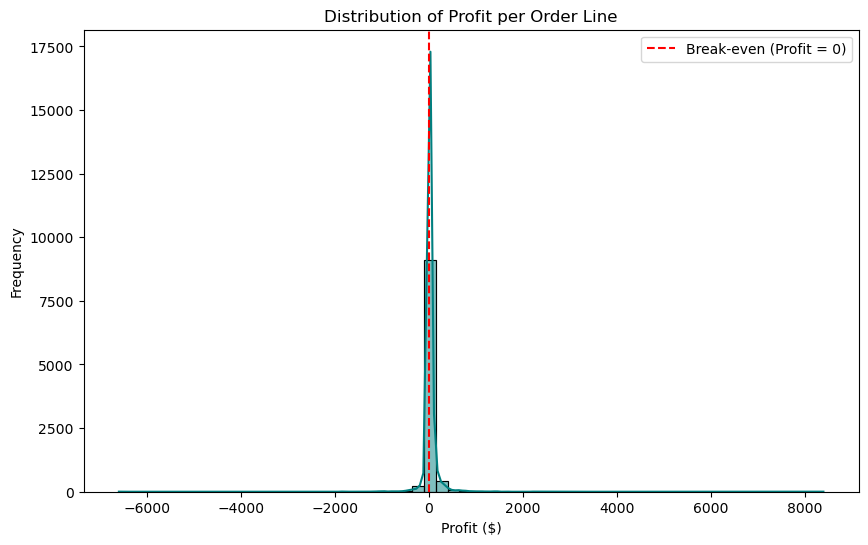

In [81]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Profit'], bins=60, kde=True, color='teal')
plt.axvline(0, color='red', linestyle='--', label='Break-even (Profit = 0)')
plt.title('Distribution of Profit per Order Line')
plt.xlabel('Profit ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


**Comments on the Plot:** 

The Profit distribution is heavily concentrated near zero and is right-skewed, with a long tail
of highly profitable outliers. Critically, a visible portion of the distribution falls to the left of the red
break-even line — meaning a non-trivial share of order lines lose money. This immediately confirms that raw sales
volume is not a reliable proxy for profitability.


#### Plot 2: Categorical Bar Chart - Total Profit by Category & Sub-Category 

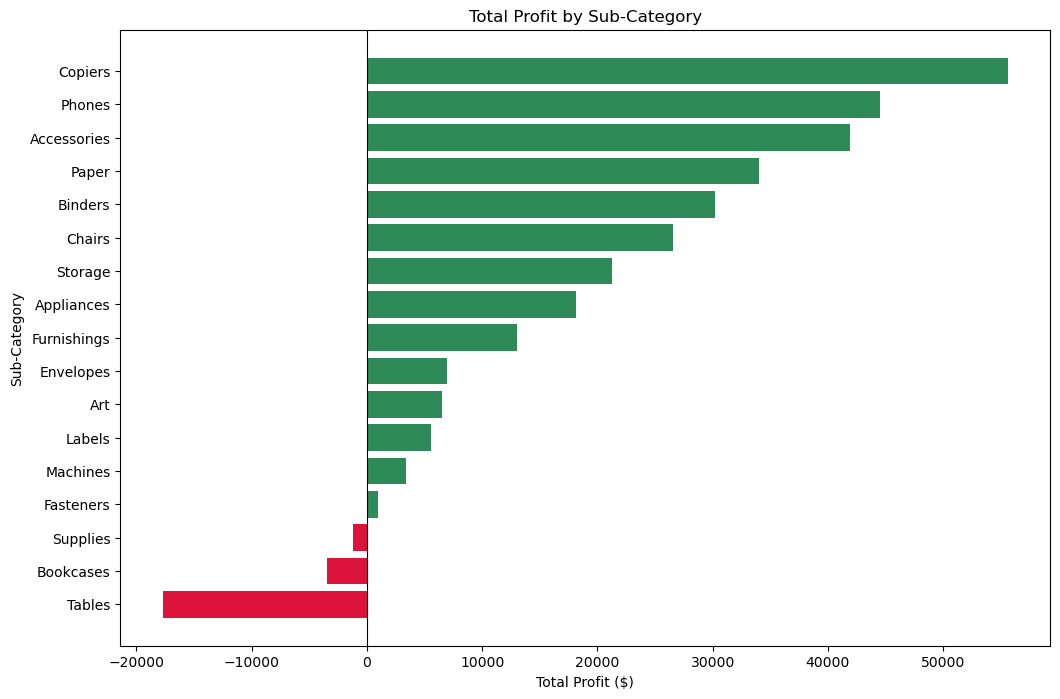

In [82]:
plt.figure(figsize=(12, 8))
plot_data = category_profit.reset_index().sort_values(by='Total_Profit')
colors = ['crimson' if x < 0 else 'seagreen' for x in plot_data['Total_Profit']]
plt.barh(plot_data['Sub-Category'], plot_data['Total_Profit'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Total Profit by Sub-Category')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')
plt.show()


**Comments on the Plot:** 

This bar chart makes loss-making sub-categories (shown in red) immediately visible against
profitable ones (green). Sub-categories like Tables and Bookcases typically show negative total profit despite
generating meaningful sales — a clear signal for a pricing or sourcing-cost review on those specific product lines.


#### Plot 3: Boxplot - Outlier detection on Discount Range vs Profit 

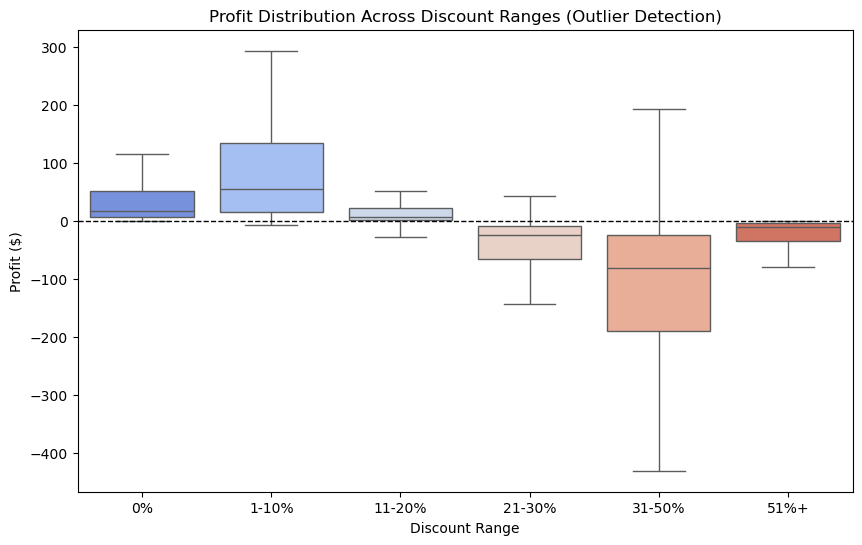

In [83]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Discount Range', y='Profit', order=discount_labels,
            hue='Discount Range', palette='coolwarm', legend=False,
            showfliers=False) 
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Profit Distribution Across Discount Ranges (Outlier Detection)')
plt.xlabel('Discount Range')
plt.ylabel('Profit ($)')
plt.show()

**Comments on the Plots:** 

The boxplots show that as discount ranges increase, the median profit line drops closer to
(and eventually below) zero, and the interquartile range shifts into negative territory at higher discount bands.
This visually confirms the tipping point where discounting stops being a growth tool and starts actively destroying
margin, while also flagging individual high-loss outlier transactions at the extreme discount levels.


#### Plot 4: Correlation Heatmap - Relatioship Between Numeric Variables 

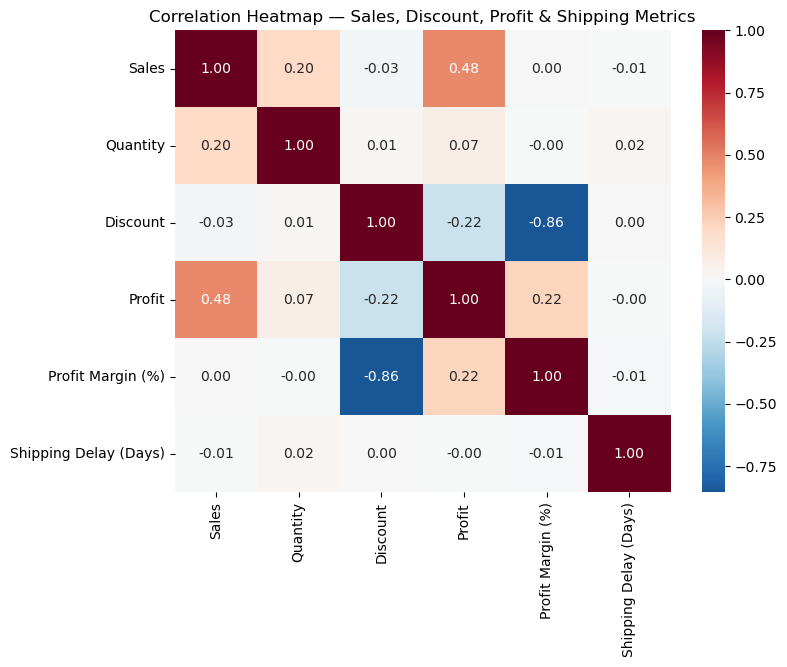

In [84]:
plt.figure(figsize=(8, 6))
corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Profit Margin (%)', 'Shipping Delay (Days)']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Correlation Heatmap — Sales, Discount, Profit & Shipping Metrics')
plt.show()


**Comments on the Plot:**

The heatmap quantifies what the boxplot suggested visually: Discount has a moderate-to-strong
negative correlation with both Profit and Profit Margin, confirming that higher discounts are systematically
associated with lower profitability. Shipping Delay shows little to no correlation with Profit, suggesting shipping
speed is not a meaningful profitability driver in this dataset.


#### Plot 5: Scatter Plot - Sales Vs Profit Colored by Discount

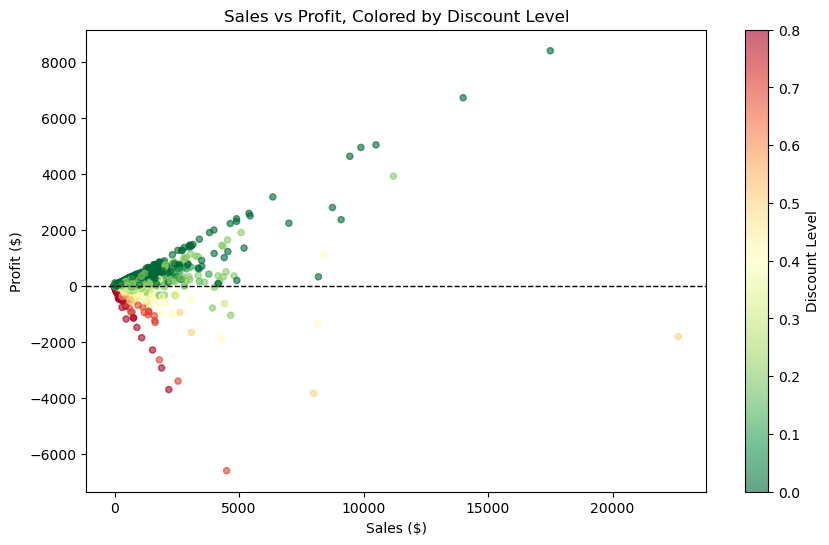

In [85]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Sales'], df['Profit'], c=df['Discount'], cmap='RdYlGn_r', alpha=0.6, s=20)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.colorbar(scatter, label='Discount Level')
plt.title('Sales vs Profit, Colored by Discount Level')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.show()


**Comments on the Plot:** 

This scatter plot shows that high-Sales transactions are not automatically high-Profit —
many large-sales orders (right side of the chart) still fall below the break-even line. Notably, the reddest
points (highest discounts) cluster heavily in the negative-profit region, reinforcing that deep discounting is
one of the clearest drivers of unprofitable orders, regardless of order size.


## 5. Key Business Takeaways / Conclusion

Based directly on the empirical analysis above:

- **Discounting has a clear tipping point.** Profit margins decline steadily as discount percentage rises, and
  orders discounted above roughly 20–30% frequently become unprofitable. Leadership should cap standard discounting
  policies below this threshold, or restrict deep discounts to specific clearance scenarios.

- **A handful of sub-categories are quietly losing money.** Certain sub-categories (e.g., Tables, Bookcases) post
  negative total profit despite meaningful sales volume — these should be reviewed for pricing, supplier cost, or
  potential delisting, rather than being scaled further.

- **High sales volume does not equal high profit efficiency by region.** Some states/regions generate large total
  sales but a low (or negative) profit-per-order, while smaller regions operate far more efficiently — resource
  allocation should follow profit efficiency, not just revenue size.

- **Shipping mode has minimal impact on profitability.** Faster shipping tiers do not measurably erode profit
  margins, so shipping speed can be optimized for customer experience without a meaningful profitability trade-off.

- **Customer segment profitability varies.** The Home Office segment yields the strongest profit-per-order, suggesting marketing and account-management resources could be
  reallocated toward this segment for the highest return.

**Overall:** Profitability at this superstore is driven far more by *discounting discipline* and *product/category
mix* than by sales volume, region size, or shipping speed - giving leadership clear, targeted levers to pull rather
than broad, unfocused cost-cutting.
